# BCO7006 — Session 11
# Data Visualization in Python
### Matplotlib · Seaborn · Plotly · 3 hours

**Where we are.** You have modelled an online store with classes (Sessions 3–6) and worked with data using NumPy/pandas (Sessions 9–10). Today you turn data into *pictures* — because some questions can only be answered by looking.

**By the end of this session you will be able to:**
- Produce the core plot types in **Matplotlib** and label them for a reader.
- Reproduce a Matplotlib plot in **Seaborn** with less code.
- Build one interactive **Plotly** chart and export it as a shareable HTML file.
- Choose the right plot for a question and a data type.
- Read an AI-generated plot critically and spot what's wrong.

> **Colab note:** Matplotlib, Seaborn, Plotly and pandas are pre-installed in Google Colab. No `pip install` needed.

## 0 · The friction: a table you can't read

We'll use `shopping_cart.csv` — the same online-store data you've seen before. Run the cell below and look at the raw table.

In [1]:
import pandas as pd

df = pd.read_csv('shopping_cart.csv')
df.head(10)

,User_ID,Product_ID,Product_Category,Quantity,Price
0,45,35,Books,2,66.988863
1,48,41,Clothes,4,57.501358
2,65,34,Books,2,28.864011
3,68,29,Books,5,35.784971
4,68,5,Groceries,8,79.875638
5,10,27,Electronics,6,20.432819
6,84,33,Books,7,12.750205
7,22,46,Books,3,53.752548
8,37,10,Groceries,6,26.026326
9,88,6,Electronics,3,27.070067


In [2]:
print(df.shape)
df.info()
df.describe()

(500, 5)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           500 non-null    int64  
 1   Product_ID        500 non-null    int64  
 2   Product_Category  500 non-null    str    
 3   Quantity          500 non-null    int64  
 4   Price             500 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 19.7 KB


,User_ID,Product_ID,Quantity,Price
count,500.000000,500.000000,500.000000,500.000000
mean,48.794000,24.980000,4.992000,52.478765
std,28.218649,14.220268,2.613349,27.491078
min,1.000000,1.000000,1.000000,5.068111
25%,25.000000,12.750000,3.000000,28.801351
50%,47.500000,26.000000,5.000000,53.093532
75%,73.000000,37.250000,7.000000,77.007687
max,99.000000,49.000000,9.000000,99.986114


**Three questions. Try to answer them by staring at the numbers above:**

1. Are most carts small-value, or is there a long tail of big spenders?
2. Which product category brings in the most revenue?
3. Does buying more units mean paying a lower price per unit?

You can't, really — not from 500 rows of text. That's what visualization is for. Let's build the pictures that answer them.

## 1 · Matplotlib — the foundation

Matplotlib is the base layer almost every other Python plotting library sits on. Learn it first; everything else is a shortcut over it.

The pattern is always the same: **make a plot, label it, show it.**

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

### 1.1 Histogram — *the shape of one numeric column*
A histogram buckets values and counts how many fall in each bucket. It answers **Question 1**: the distribution of prices.

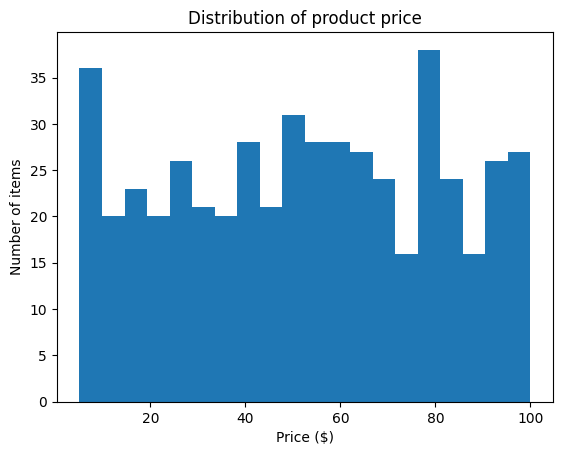

In [4]:
plt.hist(df['Price'], bins=20)
plt.title('Distribution of product price')
plt.xlabel('Price ($)')
plt.ylabel('Number of items')
plt.show()

> **Trace (predict before you run).** The next cell changes `bins=20` to `bins=5`. *Before running it*, write down: will the bars get wider or narrower? Will there be more or fewer of them?

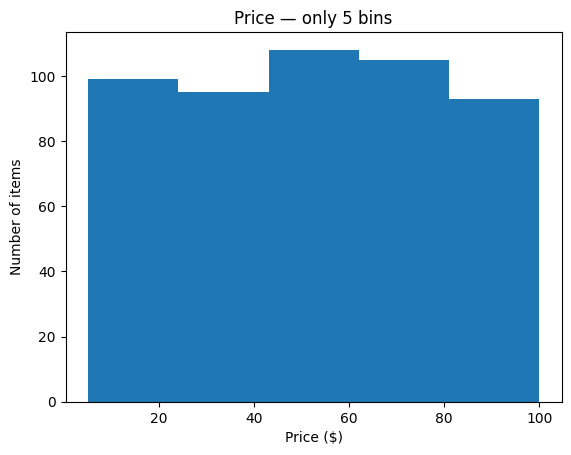

In [5]:
plt.hist(df['Price'], bins=5)
plt.title('Price — only 5 bins')
plt.xlabel('Price ($)')
plt.ylabel('Number of items')
plt.show()

### 1.2 Bar chart — *a number per category*
First we need revenue per category. Each row's revenue is `Quantity * Price`; we sum that within each category. This answers **Question 2**.

Product_Category
Books          31980.299330
Clothes        33461.680116
Electronics    31199.625557
Groceries      34259.559370
Name: LineTotal, dtype: float64


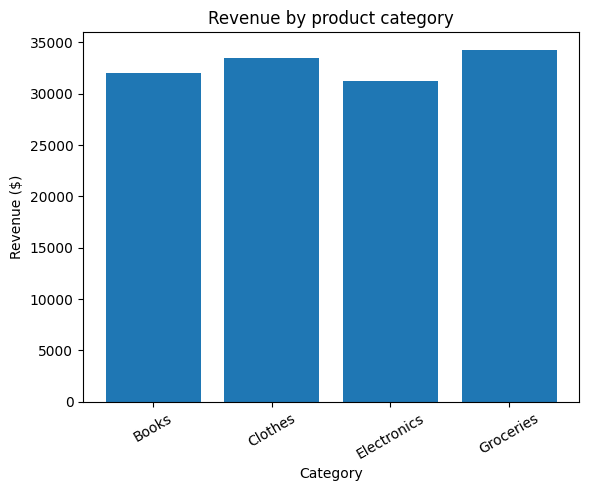

In [6]:
df['LineTotal'] = df['Quantity'] * df['Price']
revenue = df.groupby('Product_Category')['LineTotal'].sum()
print(revenue)

plt.bar(revenue.index, revenue.values)
plt.title('Revenue by product category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.show()

### 1.3 Scatter plot — *the relationship between two numeric columns*
Each point is one row: its quantity vs its price. This answers **Question 3**.

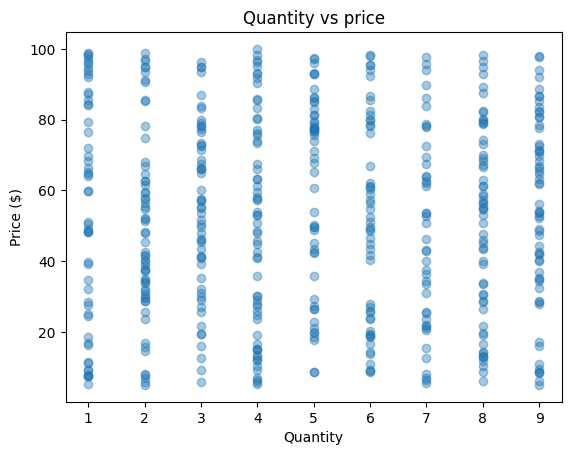

In [7]:
plt.scatter(df['Quantity'], df['Price'], alpha=0.4)
plt.title('Quantity vs price')
plt.xlabel('Quantity')
plt.ylabel('Price ($)')
plt.show()

### 1.4 Line plot — *a trend along an ordered axis*
Line plots are for data with a meaningful order (time, or a sorted numeric x). Here: average price at each quantity level.

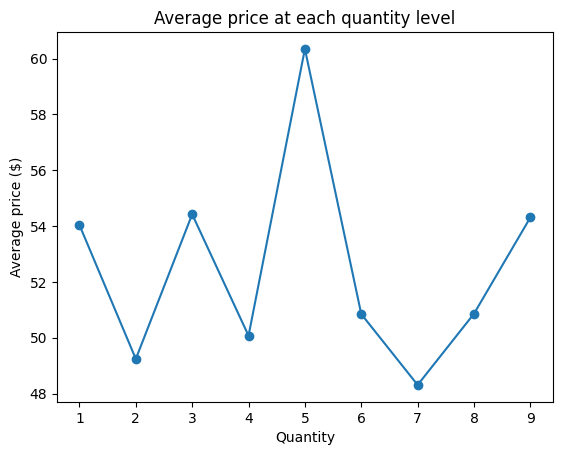

In [8]:
avg_price = df.groupby('Quantity')['Price'].mean()

plt.plot(avg_price.index, avg_price.values, marker='o')
plt.title('Average price at each quantity level')
plt.xlabel('Quantity')
plt.ylabel('Average price ($)')
plt.show()

> ⏸️ **Pause and try.** In the empty cell below, draw a histogram of the **`Quantity`** column with **15 bins**, with a title and axis labels. Leaving this blank is fine — the notebook still runs — but you'll learn more by doing it.

In [9]:
# Your turn: histogram of df['Quantity'] with 15 bins, titled and labelled.


## 2 · Seaborn — the same plots, less code, better defaults

Seaborn sits on top of Matplotlib. It gives you nicer-looking statistical plots with fewer lines, and — the big win — it can split a plot **by category** with one argument (`hue`).

In [10]:
import seaborn as sns
sns.set_theme()  # nicer default styling for all plots from here on

### 2.1 The histogram, in Seaborn
Compare this to section 1.1 — same result, and `kde=True` adds a smooth density curve for free.

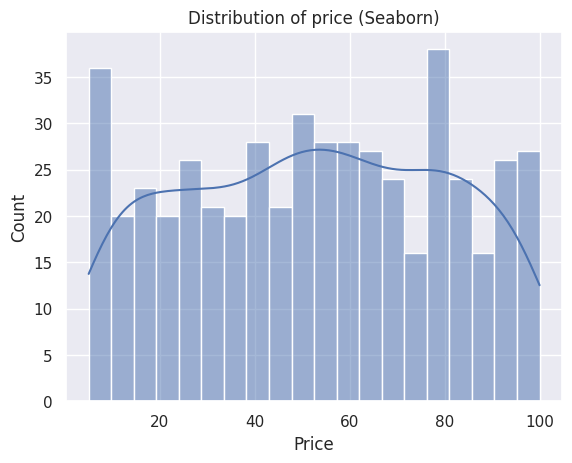

In [11]:
sns.histplot(data=df, x='Price', bins=20, kde=True)
plt.title('Distribution of price (Seaborn)')
plt.show()

### 2.2 Scatter, coloured by category — the thing Matplotlib made hard
One argument, `hue='Product_Category'`, colours each point by its category. Doing this in plain Matplotlib means a manual loop.

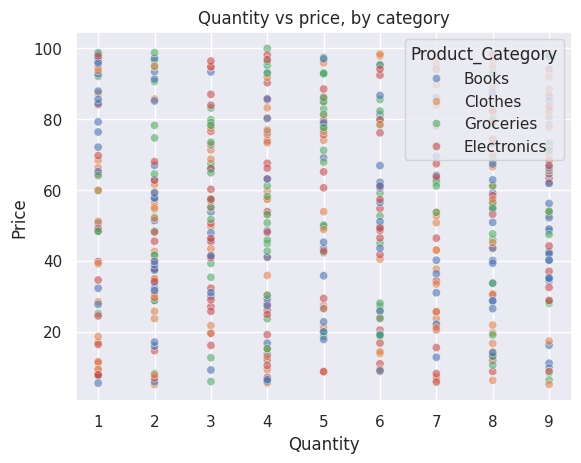

In [12]:
sns.scatterplot(data=df, x='Quantity', y='Price', hue='Product_Category', alpha=0.6)
plt.title('Quantity vs price, by category')
plt.show()

> ⏸️ **Pause and try.** Use `sns.barplot(data=df, x=..., y=...)` to show **average `Price` per `Product_Category`**. (Seaborn averages for you — no `groupby` needed.)

In [13]:
# Your turn: sns.barplot of average Price per Product_Category.


## 3 · Plotly — interactive, and shareable

Matplotlib and Seaborn make *static* images. **Plotly** makes charts a reader can hover, zoom, and pan — and you can save one as a standalone HTML file to email to a stakeholder.

`plotly.express` is the quick, high-level interface.

In [14]:
import plotly.express as px

fig = px.scatter(
    df, x='Quantity', y='Price', color='Product_Category',
    hover_data=['User_ID', 'Product_ID'],
    title='Quantity vs price (interactive)'
)
fig.show()

### 3.1 Export to a shareable file
This writes a self-contained HTML file. Open it in any browser — the interactivity travels with it. In Colab, find it in the file browser on the left and download it.

In [15]:
fig.write_html('quantity_vs_price.html')
print('Saved quantity_vs_price.html — download it from the Colab file browser.')

Saved quantity_vs_price.html — download it from the Colab file browser.


> ⏸️ **Pause and try.** Make an interactive Plotly **histogram** of `Price` with `px.histogram(df, x='Price', nbins=20)`, give it a title, and `fig.show()` it.

In [16]:
# Your turn: an interactive Plotly histogram of Price.


## 4 · Which plot, when?

The hard part isn't syntax — it's choosing. A quick heuristic:

| You want to show… | Use |
|---|---|
| The shape/spread of **one numeric** column | Histogram |
| A value for **each category** | Bar chart |
| The **relationship** between two numeric columns | Scatter |
| A **trend** along an ordered axis (time, sorted number) | Line |
| The same, but a reader should **explore** it | Any of the above in Plotly |

**The other four libraries** you saw named (Bokeh, Altair, ggplot/plotnine) are real and useful, but you don't need them yet:
- **Bokeh** — interactive dashboards for the web (overlaps Plotly).
- **Altair** — concise, declarative grammar-of-graphics syntax.
- **ggplot / plotnine** — for people coming from R's `ggplot2`.

Reach for them later if a project needs them. For this unit: Matplotlib + Seaborn + Plotly is plenty.

## 5 · Mini-project — answer the business questions (≈35 min)

You now have everything you need. For **each** question below, decide which plot type fits, build it, and write one sentence of what it tells you. The plot choice is the graded skill — not the syntax.

**Q1.** What does the distribution of **cart line totals** (`LineTotal`) look like? Is there a long tail?
**Q2.** Which **category** has the highest *average* line total?
**Q3.** Among **Books only**, is there any relationship between quantity and price?
**Open (Extend).** Ask a question of your own about this data, build the chart that answers it, and export an **interactive** version with `write_html`.

In [17]:
# Q1 — your plot here (hint: which plot shows the shape of one numeric column?)


In [18]:
# Q2 — your plot here (hint: a number per category)


In [19]:
# Q3 — your plot here (hint: filter first -> books = df[df['Product_Category'] == 'Books'])


In [20]:
# Open question — your interactive chart + write_html here


## 6 · AI critique (≈15 min) — read generated code like a professional

You will use AI to write plotting code in your career. The skill that matters is catching what it gets wrong.

**An LLM was asked: "plot the average price per category as a line chart." It returned this:**

```python
plt.plot(df['Product_Category'], df['Price'])
plt.title('Average price per category')
plt.show()
```

**In the cell below, write down at least two things wrong with this snippet**, then write a corrected version that actually plots the *average* price per category with an appropriate plot type.

(Hints to check: Is it plotting an *average*? Is a *line* the right choice for *categories*? What happens to the x-axis with 500 unlabelled category strings?)

In [21]:
# Your critique (as comments) + your corrected plot.
# What's wrong:
# 1.
# 2.

# Corrected version:


### Reflection — required
If you used an AI tool anywhere in this notebook, paste your prompt(s) and one sentence on what you changed in its output. If you didn't, say so. This is part of how this unit treats AI: visible, not banned.

In [22]:
# Reflection (text in a comment is fine):
# Prompt used:
# What I changed:


## 7 · Skill check — code completion

Fill the blank so each line does what the comment says. Replace `____`. (Answers are in the instructor notebook.)

```python
# 1. histogram of Price with 30 bins
plt.hist(df['Price'], ____=30)

# 2. label the x-axis 'Price ($)'
plt.____('Price ($)')

# 3. seaborn scatter coloured by category
sns.scatterplot(data=df, x='Quantity', y='Price', ____='Product_Category')

# 4. revenue summed per category
df.groupby('Product_Category')['LineTotal'].____()

# 5. save a Plotly figure to a shareable file
fig.____('chart.html')
```
Type your answers in the cell below.

In [23]:
# 1.
# 2.
# 3.
# 4.
# 5.


## ✅ Before you leave
- [ ] Notebook runs top-to-bottom with no errors (Runtime ▸ Restart and run all)
- [ ] All three mini-project questions have a plot **and** a one-sentence finding
- [ ] You exported at least one interactive chart to HTML
- [ ] AI reflection cell is filled in

**Next session:** APIs — getting data that *doesn't* come in a CSV.